In [1]:
from tensorflow.keras.models import load_model

# Charger le modèle
model = load_model("mobilenetv2_finetuned_best.keras")

# Afficher l’architecture du modèle
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 4,681,675 (17.86 MB)

 Trainable params: 1,209,923 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,419,848 (9.23 MB)

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

def create_qlf_system():
    # --- ANTECEDENTS (Entrées) ---
    # La probabilité maximale donnée par le CNN
    max_prob = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'max_prob')
    # L'écart entre la 1ère et la 2ème probabilité (mesure de l'hésitation)
    gap = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'gap')

    # --- CONSEQUENT (Sortie) ---
    reliability = ctrl.Consequent(np.arange(0, 101, 1), 'reliability')

    # --- FUZZIFICATION ---
    max_prob['low'] = fuzz.trimf(max_prob.universe, [0, 0, 0.6])
    max_prob['medium'] = fuzz.trimf(max_prob.universe, [0.4, 0.7, 0.85])
    max_prob['high'] = fuzz.trimf(max_prob.universe, [0.75, 1, 1])

    gap['small'] = fuzz.trimf(gap.universe, [0, 0, 0.2])
    gap['large'] = fuzz.trimf(gap.universe, [0.15, 1, 1])

    reliability['uncertain'] = fuzz.trimf(reliability.universe, [0, 0, 50])
    reliability['reliable'] = fuzz.trimf(reliability.universe, [40, 75, 100])
    reliability['very_reliable'] = fuzz.trimf(reliability.universe, [80, 100, 100])

    # --- RÈGLES D'INFERENCE (L'intelligence du système) ---
    rule1 = ctrl.Rule(max_prob['high'] & gap['large'], reliability['very_reliable'])
    rule2 = ctrl.Rule(max_prob['medium'] | gap['small'], reliability['reliable'])
    rule3 = ctrl.Rule(max_prob['low'], reliability['uncertain'])

    qlf_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
    return ctrl.ControlSystemSimulation(qlf_ctrl)

qlf_sim = create_qlf_system()

In [3]:
def predict_hybrid_qlf(img_path, model, qlf_sim):
    # A. Prétraitement de l'image (standard pour MobileNetV2)
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # B. Étape CNN (Perception)
    predictions = model.predict(img_array)
    probabilities = predictions[0] # [p_child, p_adult, p_senior]
    
    # Trouver la classe gagnante et la seconde
    sorted_indices = np.argsort(probabilities)[::-1]
    best_class_idx = sorted_indices[0]
    second_class_idx = sorted_indices[1]
    
    max_p = probabilities[best_class_idx]
    second_p = probabilities[second_class_idx]
    current_gap = max_p - second_p

    # C. Étape QLF (Jugement Qualitatif)
    qlf_sim.input['max_prob'] = max_p
    qlf_sim.input['gap'] = current_gap
    qlf_sim.compute()
    
    reliability_score = qlf_sim.output['reliability']

    # D. Interprétation des labels
    labels = ["Child", "Adult", "Senior"]
    final_label = labels[best_class_idx]
    
    # Classification du niveau de confiance
    if reliability_score >= 80:
        status = "High Reliability"
    elif reliability_score >= 50:
        status = "Reliable (Caution)"
    else:
        status = "Uncertain / Transition Zone"

    return {
        "prediction": final_label,
        "confidence_cnn": f"{max_p*100:.1f}%",
        "reliability_qlf": f"{reliability_score:.1f}/100",
        "status": status,
        "raw_probs": probabilities
    }

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Configuration (doit être identique au Notebook Modèle 2)
DATA_DIR = "faces_dataset"
CSV_FILE = "labels_corrected.csv"
df = pd.read_csv(CSV_FILE)

# 2. Préparation des chemins
df["path"] = df["image_name"].apply(lambda x: os.path.join(DATA_DIR, x))
df["label"] = df["label"].astype(str)

# 3. LE SPLIT CRUCIAL
# En gardant test_size=0.30 et random_state=42, test_df sera IDENTIQUE
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(f"Nombre d'images de test retrouvées : {len(test_df)}")
# Vérification visuelle (optionnel)
print(test_df.head(3))

Nombre d'images de test retrouvées : 3519
                                  image_name label  \
2978   21_0_4_20161223214821265.jpg.chip.jpg     1   
10726  30_1_0_20170104192455647.jpg.chip.jpg     1   
13794  36_0_4_20170103230431017.jpg.chip.jpg     1   

                                                    path  
2978   faces_dataset\21_0_4_20161223214821265.jpg.chi...  
10726  faces_dataset\30_1_0_20170104192455647.jpg.chi...  
13794  faces_dataset\36_0_4_20170103230431017.jpg.chi...  


In [5]:
import tensorflow as tf
import numpy as np
# Assure-toi aussi que pandas et tqdm sont là
import pandas as pd
from tqdm import tqdm

In [6]:
import tqdm # Pour voir la barre de progression

def evaluate_qlf_system(test_dataframe, model, qlf_sim):
    qlf_results = []
    
    print(f"Évaluation de QLF sur {len(test_dataframe)} images...")
    
    for index, row in tqdm.tqdm(test_dataframe.iterrows(), total=len(test_dataframe)):
        img_path = row['path'] 
        true_label_idx = int(row['label']) # Label réel (0, 1 ou 2)
        
        # Mapping des noms pour la comparaison
        labels_map = {0: "Child", 1: "Adult", 2: "Senior"}
        true_label_name = labels_map[true_label_idx]
        
        # Exécuter la prédiction QLF
        try:
            res = predict_hybrid_qlf(img_path, model, qlf_sim)
            
            # Comparaison
            is_correct = (res['prediction'] == true_label_name)
            
            qlf_results.append({
                'Image': row['image_name'],
                'True_Label': true_label_name,
                'Predicted_Label': res['prediction'],
                'Is_Correct': is_correct,
                'CNN_Max_Prob': float(res['confidence_cnn'].replace('%','')),
                'QLF_Reliability': float(res['reliability_qlf'].split('/')[0]),
                'Status': res['status']
            })
        except Exception as e:
            print(f"Erreur sur l'image {img_path}: {e}")
            
    return pd.DataFrame(qlf_results)

# Lancement de l'évaluation
# Note : Tu peux tester sur un échantillon (ex: .head(500)) pour aller plus vite au début
df_final_results = evaluate_qlf_system(test_df, model, qlf_sim)

Évaluation de QLF sur 3519 images...


  0%|                                                                                         | 0/3519 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  0%|                                                                               | 1/3519 [00:02<2:06:57,  2.17s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


...

100%|█████████████████████████████████████████████████████████████████████████████▉| 3517/3519 [08:57<00:00,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


100%|█████████████████████████████████████████████████████████████████████████████▉| 3518/3519 [08:57<00:00,  5.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


100%|██████████████████████████████████████████████████████████████████████████████| 3519/3519 [08:58<00:00,  6.54it/s]


In [13]:
# Analyse par niveau de fiabilité QLF
stats = df_final_results.groupby('Status').agg({
    'Is_Correct': ['count', 'mean'],
    'QLF_Reliability': 'mean'
})

# Renommer pour la clarté
stats.columns = ['Nombre d\'images', 'Accuracy (Précision)', 'Score QLF Moyen']
stats['Accuracy (Précision)'] = (stats['Accuracy (Précision)'] * 100).round(2).astype(str) + '%'
stats['Score QLF Moyen'] = stats['Score QLF Moyen'].round(2)

print("--- ANALYSE DE FIABILITÉ QLF ---")
print(stats)

--- ANALYSE DE FIABILITÉ QLF ---
                    Nombre d'images Accuracy (Précision)  Score QLF Moyen
Status                                                                   
High Reliability               3244               93.13%            93.21
Reliable (Caution)              275               56.73%            70.11


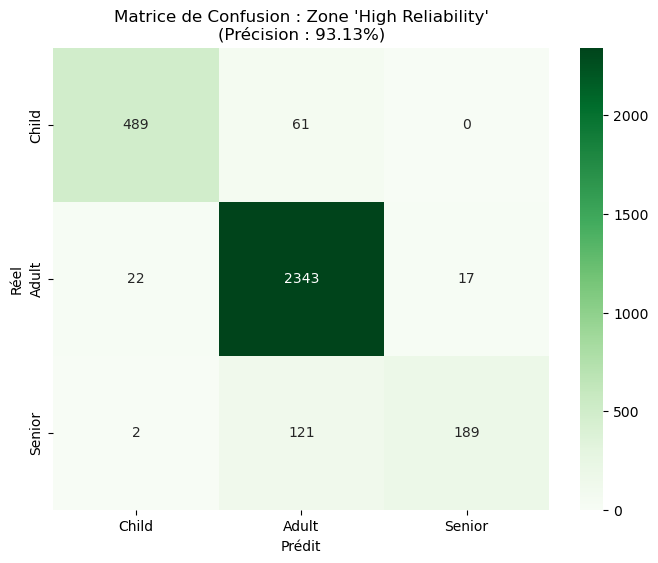

Rapport de classification (Haute Fiabilité) :
              precision    recall  f1-score   support

       Child       0.93      0.98      0.95      2382
       Adult       0.95      0.89      0.92       550
      Senior       0.92      0.61      0.73       312

    accuracy                           0.93      3244
   macro avg       0.93      0.83      0.87      3244
weighted avg       0.93      0.93      0.93      3244



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# On filtre uniquement les prédictions haute fiabilité
df_high = df_final_results[df_final_results['Status'] == 'High Reliability']

# Labels
labels = ["Child", "Adult", "Senior"]

# Calcul de la matrice
cm_high = confusion_matrix(df_high['True_Label'], df_high['Predicted_Label'], labels=labels)

# Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(cm_high, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.title("Matrice de Confusion : Zone 'High Reliability'\n(Précision : 93.13%)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print("Rapport de classification (Haute Fiabilité) :")
print(classification_report(df_high['True_Label'], df_high['Predicted_Label'], target_names=labels))

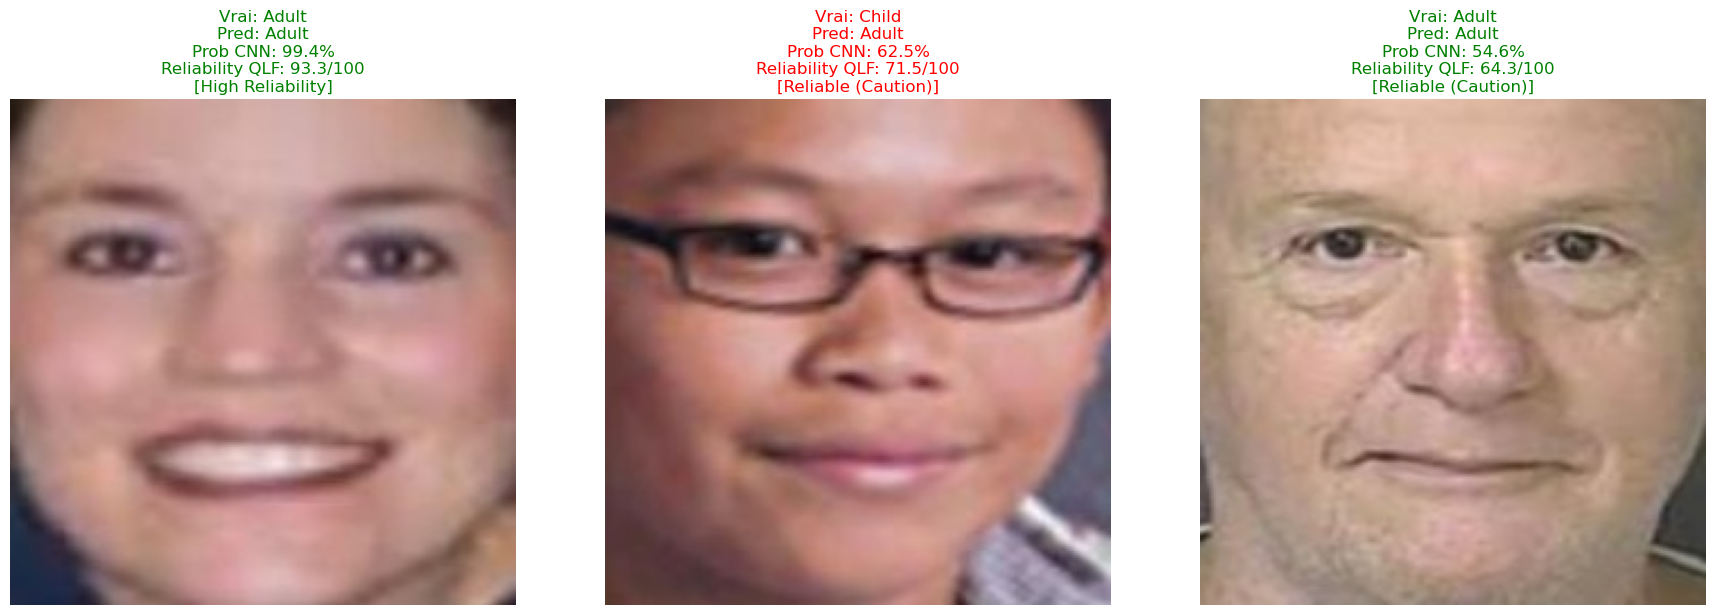

In [35]:
import matplotlib.pyplot as plt
import cv2
import os

def display_comparative_results(df, data_dir, num_examples=6):
    # 1. Cas "Idéal" (Correct & High Reliability)
    ideal_cases = df[(df['Is_Correct'] == True) & (df['Status'] == 'High Reliability')].head(1)
    
    # 2. Cas "Erreur Softmax sauvée par QLF" (Incorrect & Caution)
    saved_cases = df[(df['Is_Correct'] == False) & (df['Status'] == 'Reliable (Caution)')].head(1)
    
    # 3. Cas "Incertain" (Le CNN a raison mais QLF doute)
    ambiguous_cases = df[(df['Is_Correct'] == True) & (df['Status'] == 'Reliable (Caution)')].head(1)
    
    examples = pd.concat([ideal_cases, saved_cases, ambiguous_cases])
    
    plt.figure(figsize=(18, 6))
    
    for i, (idx, row) in enumerate(examples.iterrows()):
        img_path = os.path.join(data_dir, row['Image'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        color = 'green' if row['Is_Correct'] else 'red'
        
        title = f"Vrai: {row['True_Label']}\nPred: {row['Predicted_Label']}\n"
        title += f"Prob CNN: {row['CNN_Max_Prob']}%\nReliability QLF: {row['QLF_Reliability']}/100\n"
        title += f"[{row['Status']}]"
        
        plt.title(title, color=color, fontsize=12)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Utilisation (DATA_DIR est ton dossier faces_dataset)
display_comparative_results(df_final_results, DATA_DIR)

In [29]:
total = len(df_final_results)

# 1. CONFIRMATION (Succès partagé) : Les deux ont raison et QLF est confiant
confirmation = len(df_final_results[(df_final_results['Is_Correct'] == True) & (df_final_results['Status'] == 'High Reliability')])

# 2. SÉCURITÉ (QLF sauve l'erreur) : MobileNet a tort, mais QLF prévient (Caution)
security_save = len(df_final_results[(df_final_results['Is_Correct'] == False) & (df_final_results['Status'] == 'Reliable (Caution)')])

# 3. PRUDENCE (Faux doute) : MobileNet a raison, mais QLF est méfiant (Caution)
prudence_check = len(df_final_results[(df_final_results['Is_Correct'] == True) & (df_final_results['Status'] == 'Reliable (Caution)')])

# 4. ÉCHEC CRITIQUE (Erreur non détectée) : MobileNet a tort et QLF est confiant
critical_failure = len(df_final_results[(df_final_results['Is_Correct'] == False) & (df_final_results['Status'] == 'High Reliability')])

print(f"--- RÉSULTATS COMPARATIFS (Total: {total} images) ---")
print(f"✅ Confirmation (Succès Robuste) : {(confirmation/total)*100:.2f}%")
print(f"🛡️ Sécurité (Erreur CNN détectée par QLF) : {(security_save/total)*100:.2f}%")
print(f"⚠️ Prudence (Doute QLF sur succès CNN) : {(prudence_check/total)*100:.2f}%")
print(f"❌ Échec Critique (Erreur non détectée) : {(critical_failure/total)*100:.2f}%")

--- RÉSULTATS COMPARATIFS (Total: 3519 images) ---
✅ Confirmation (Succès Robuste) : 85.85%
🛡️ Sécurité (Erreur CNN détectée par QLF) : 3.38%
⚠️ Prudence (Doute QLF sur succès CNN) : 4.43%
❌ Échec Critique (Erreur non détectée) : 6.34%
